
# PyTorch FNN Regression

이 노트북은 Google Drive의 `test.csv`를 불러와 다음 작업을 수행합니다.

- 입력: `data1`
- 출력: `data2`
- Train/Test 데이터는 동일하게 사용
- 표준화
- PyTorch 기반 FNN 회귀모델 학습
- Epoch별 Train/Test loss 저장
- 실제값/추정값 비교 그림 저장
- 추정 결과 CSV 저장
- 학습 모델 및 scaler 저장


In [ ]:

# 1. 라이브러리 및 Google Drive 연결

import os
import random
import copy
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from google.colab import drive

# GitHub repository를 저장할 위치
REPO_ROOT = "/content/Basic_example_copy"
# 저장소가 없으면 clone
if not os.path.exists(REPO_ROOT):
    !git clone -q https://github.com/Jaehoon-Shim/Basic_example.git {REPO_ROOT}
os.makedirs('/content/Basic_example_copy/data', exist_ok=True)
os.makedirs('/content/Basic_example_copy/results', exist_ok=True)


Mounted at /content/drive


In [ ]:

# 2. 설정

SEED = 42
EPOCHS = 2800
LEARNING_RATE = 1e-3
PRINT_INTERVAL = 1

BASE_DIR = '/content/Basic_example_copy'
RESULT_DIR = os.path.join(BASE_DIR, 'results')
CSV_PATH = os.path.join(BASE_DIR, 'data/test.csv')

os.makedirs(RESULT_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Device    :', DEVICE)
print('CSV Path  :', CSV_PATH)
print('Result Dir:', RESULT_DIR)
print('CSV Exists:', os.path.exists(CSV_PATH))


Device    : cpu
CSV Path  : /content/drive/MyDrive/Colab Notebooks/Basic_example/data/test.csv
Result Dir: /content/drive/MyDrive/Colab Notebooks/Basic_example/data/pytorch_results
CSV Exists: True


In [ ]:

# 3. CSV 로드 및 전처리
df = pd.read_csv(CSV_PATH)

# 불필요한 인덱스 열 제거
df = df.loc[:, ~df.columns.astype(str).str.startswith('Unnamed')]

required_columns = ['data1', 'data2']

if not all(col in df.columns for col in required_columns):
    raise ValueError(
        f'CSV에 {required_columns} 열이 필요합니다. '
        f'현재 열: {df.columns.tolist()}'
    )

df = df[required_columns].copy()

df['data1'] = pd.to_numeric(df['data1'], errors='coerce')
df['data2'] = pd.to_numeric(df['data2'], errors='coerce')

df = df.dropna().reset_index(drop=True)

print('Data shape:', df.shape)
display(df.head())
display(df.describe())


Data shape: (400, 2)


,data1,data2
0,0.000000,7.438766
1,0.100251,7.311275
2,0.200501,7.496599
3,0.300752,7.701600
4,0.401003,7.327267


,data1,data2
count,400.000000,400.000000
mean,20.000000,5.441844
std,11.590406,3.665019
min,0.000000,0.200000
25%,10.000000,2.509633
50%,20.000000,4.464003
75%,30.000000,7.972711
max,40.000000,16.573641


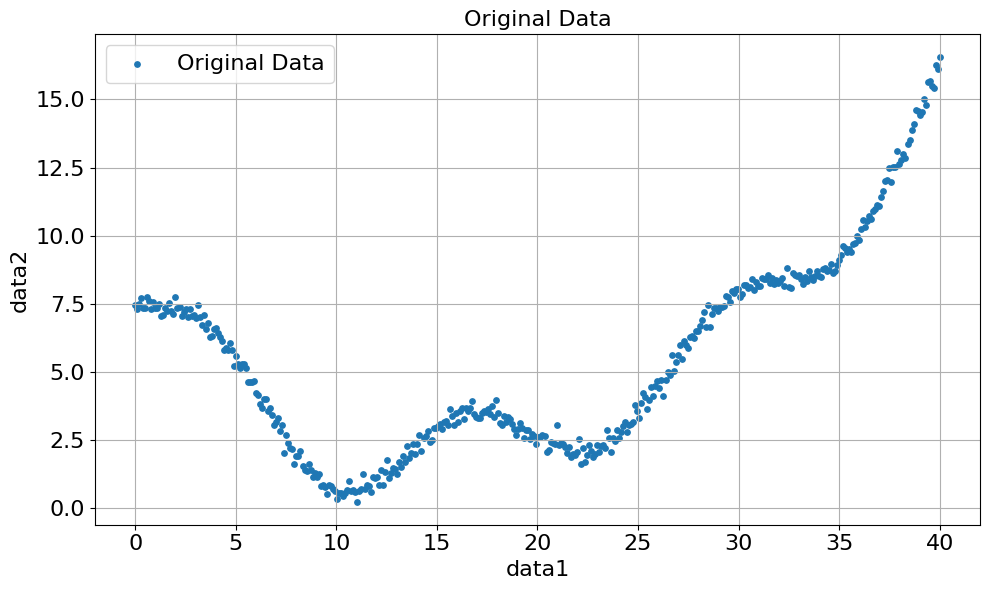

Saved: /content/drive/MyDrive/Colab Notebooks/Basic_example/data/pytorch_results/original_data.jpg


In [ ]:
# 3-1. 원본 데이터 플롯

plt.figure(figsize=(10, 6))

plt.scatter(
    df['data1'],
    df['data2'],
    s=15,
    label='Original Data'
)

plt.xlabel('data1', fontsize=16)
plt.ylabel('data2', fontsize=16)
plt.title('Original Data', fontsize=16)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.grid(True)
plt.legend(fontsize=16)
plt.tight_layout()

original_data_path = os.path.join(
    RESULT_DIR,
    'original_data.jpg'
)

plt.savefig(original_data_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', original_data_path)


In [ ]:

# 4. 입력/출력 구성 및 표준화

X = df[['data1']].to_numpy(dtype=np.float32)
y = df[['data2']].to_numpy(dtype=np.float32)

# 요청에 따라 train/test 동일
X_train = X.copy()
y_train = y.copy()

X_test = X.copy()
y_test = y.copy()

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train).astype(np.float32)
y_train_scaled = y_scaler.fit_transform(y_train).astype(np.float32)

X_test_scaled = x_scaler.transform(X_test).astype(np.float32)
y_test_scaled = y_scaler.transform(y_test).astype(np.float32)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32, device=DEVICE)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32, device=DEVICE)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32, device=DEVICE)

print('X_train:', X_train_tensor.shape)
print('y_train:', y_train_tensor.shape)


X_train: torch.Size([400, 1])
y_train: torch.Size([400, 1])


In [ ]:

# 5. FNN 모델 정의

class FNNRegressor(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(1, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.model(x)


model = FNNRegressor().to(DEVICE)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=100
)

print(model)


FNNRegressor(
  (model): Sequential(
    (0): Linear(in_features=1, out_features=24, bias=True)
    (1): Linear(in_features=24, out_features=24, bias=True)
    (2): Linear(in_features=24, out_features=24, bias=True)
    (3): Linear(in_features=24, out_features=24, bias=True)
    (4): Linear(in_features=24, out_features=1, bias=True)
  )
)


In [ ]:

# 6. 모델 학습

train_loss_history = []
test_loss_history = []

best_test_loss = float('inf')
best_model_state = None

for epoch in range(1, EPOCHS + 1):

    # Train
    model.train()

    optimizer.zero_grad()

    train_pred = model(X_train_tensor)
    train_loss = criterion(train_pred, y_train_tensor)

    train_loss.backward()
    optimizer.step()

    # Test
    model.eval()

    with torch.no_grad():
        test_pred = model(X_test_tensor)
        test_loss = criterion(test_pred, y_test_tensor)

    train_loss_value = train_loss.item()
    test_loss_value = test_loss.item()

    train_loss_history.append(train_loss_value)
    test_loss_history.append(test_loss_value)

    scheduler.step(test_loss_value)

    if test_loss_value < best_test_loss:
        best_test_loss = test_loss_value
        best_model_state = copy.deepcopy(model.state_dict())

    if epoch == 1 or epoch % PRINT_INTERVAL == 0:
        current_lr = optimizer.param_groups[0]['lr']

        print(
            f'Epoch {epoch:4d}/{EPOCHS} | '
            f'Train Loss: {train_loss_value:.8f} | '
            f'Test Loss: {test_loss_value:.8f} | '
            f'LR: {current_lr:.6f}'
        )

model.load_state_dict(best_model_state)

print()
print('Best Test Loss:', best_test_loss)


Epoch    1/800 | Train Loss: 1.12360454 | Test Loss: 1.06765318 | LR: 0.001000
Epoch    2/800 | Train Loss: 1.06765318 | Test Loss: 1.01698589 | LR: 0.001000
Epoch    3/800 | Train Loss: 1.01698589 | Test Loss: 0.97086573 | LR: 0.001000
Epoch    4/800 | Train Loss: 0.97086573 | Test Loss: 0.92865592 | LR: 0.001000
Epoch    5/800 | Train Loss: 0.92865592 | Test Loss: 0.88984931 | LR: 0.001000
Epoch    6/800 | Train Loss: 0.88984931 | Test Loss: 0.85411400 | LR: 0.001000
Epoch    7/800 | Train Loss: 0.85411400 | Test Loss: 0.82125807 | LR: 0.001000
Epoch    8/800 | Train Loss: 0.82125807 | Test Loss: 0.79117197 | LR: 0.001000
Epoch    9/800 | Train Loss: 0.79117197 | Test Loss: 0.76380044 | LR: 0.001000
Epoch   10/800 | Train Loss: 0.76380044 | Test Loss: 0.73913360 | LR: 0.001000
Epoch   11/800 | Train Loss: 0.73913360 | Test Loss: 0.71720177 | LR: 0.001000
Epoch   12/800 | Train Loss: 0.71720177 | Test Loss: 0.69806951 | LR: 0.001000
Epoch   13/800 | Train Loss: 0.69806951 | Test Loss:

In [ ]:
# 7. 추정 및 역표준화

model.eval()

# Train/Test 추정
with torch.no_grad():
    y_train_pred_scaled = model(X_train_tensor).cpu().numpy()
    y_test_pred_scaled = model(X_test_tensor).cpu().numpy()

y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled)
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled)

# 플롯용: 전체 원본 입력 데이터에 대해 y_pred 계산
X_all = X.copy()
X_all_scaled = x_scaler.transform(X_all).astype(np.float32)
X_all_tensor = torch.tensor(X_all_scaled, dtype=torch.float32, device=DEVICE)

with torch.no_grad():
    y_all_pred_scaled = model(X_all_tensor).cpu().numpy()

y_all_pred = y_scaler.inverse_transform(y_all_pred_scaled)

print('Actual sample   :', y[:5].flatten())
print('Predicted sample:', y_all_pred[:5].flatten())


Actual sample   : [7.438766  7.311275  7.4965987 7.7016006 7.3272676]
Predicted sample: [1.6721989 1.6910936 1.7099897 1.7288853 1.7477807]


In [ ]:

# 8. 성능지표

def evaluate(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f'[{name}]')
    print(f'MSE  : {mse:.8f}')
    print(f'RMSE : {rmse:.8f}')
    print(f'MAE  : {mae:.8f}')
    print(f'R²   : {r2:.8f}')
    print()

    return mse, rmse, mae, r2


train_metrics = evaluate(y_train, y_train_pred, 'Train')
test_metrics = evaluate(y_test, y_test_pred, 'Test')


[Train]
MSE  : 8.63942337
RMSE : 2.93928960
MAE  : 2.45354986
R²   : 0.35520822

[Test]
MSE  : 8.63942337
RMSE : 2.93928960
MAE  : 2.45354986
R²   : 0.35520822



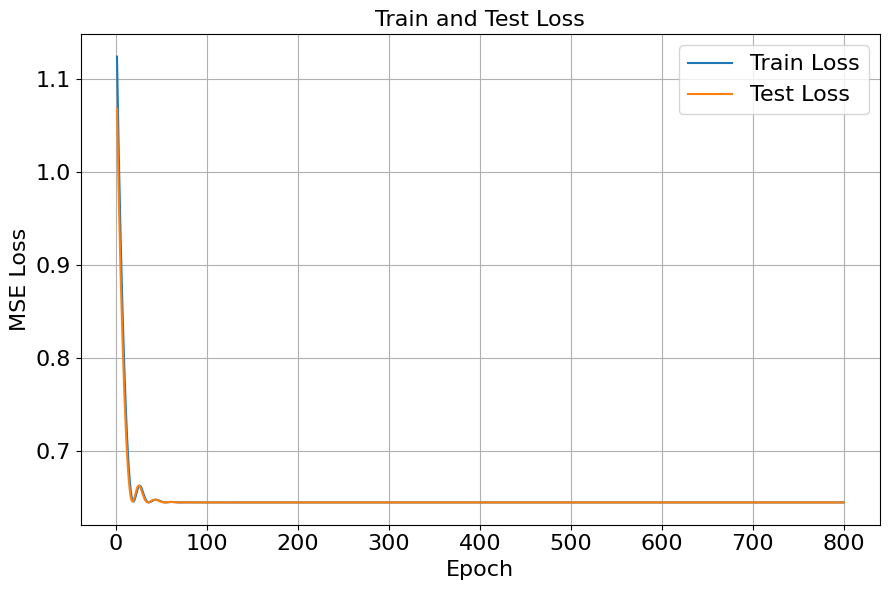

Saved: /content/drive/MyDrive/Colab Notebooks/Basic_example/data/pytorch_results/train_test_loss.jpg


In [ ]:

# 9. Epoch별 Train/Test loss 저장

epochs = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(9, 6))

plt.plot(epochs, train_loss_history, label='Train Loss')
plt.plot(epochs, test_loss_history, label='Test Loss')


plt.xlabel('Epoch', fontsize=16)
plt.ylabel('MSE Loss', fontsize=16)
plt.title('Train and Test Loss', fontsize=16)
plt.grid(True)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)

plt.tight_layout()

loss_path = os.path.join(
    RESULT_DIR,
    'train_test_loss.jpg'
)

plt.savefig(loss_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', loss_path)


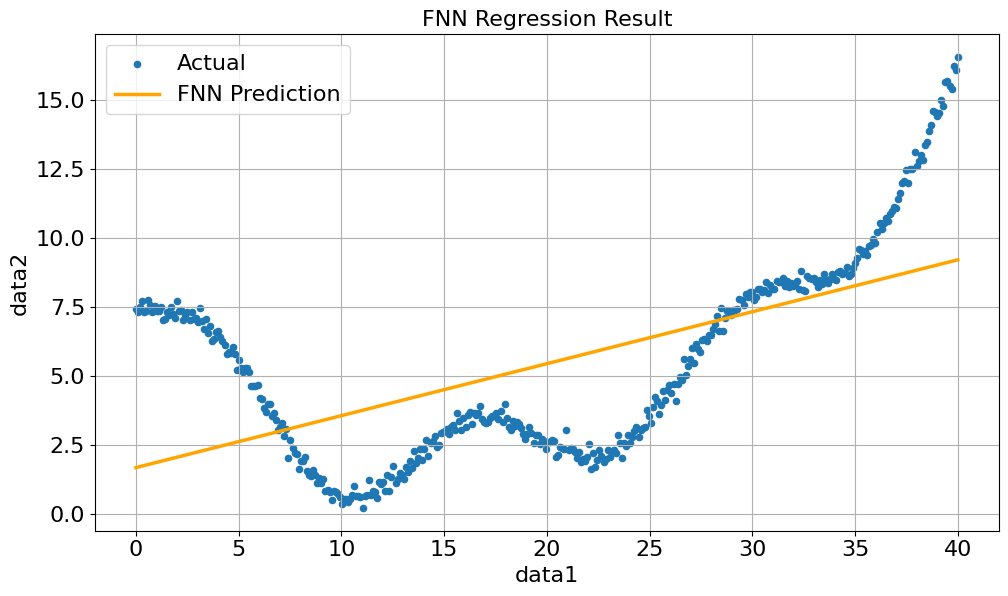

Saved: /content/drive/MyDrive/Colab Notebooks/Basic_example/data/pytorch_results/fnn_regression_result.jpg


In [ ]:
# 10. 전체 데이터 기준 회귀 평가 결과

# 전체 입력 데이터를 x축 기준으로 정렬
sort_idx = np.argsort(X_all.flatten())

x_sorted = X_all.flatten()[sort_idx]
y_actual_sorted = y.flatten()[sort_idx]
y_pred_sorted = y_all_pred.flatten()[sort_idx]

plt.figure(figsize=(10, 6))

# 원본 데이터
plt.scatter(
    x_sorted,
    y_actual_sorted,
    s=20,
    label='Actual'
)

# 평가 결과(y_pred)는 주황색으로 표시
plt.plot(
    x_sorted,
    y_pred_sorted,
    color='orange',
    linewidth=2.5,
    label='FNN Prediction'
)

plt.xlabel('data1', fontsize=16)
plt.ylabel('data2', fontsize=16)
plt.title('FNN Regression Result', fontsize=16)
plt.grid(True)
plt.tight_layout()

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)

regression_path = os.path.join(
    RESULT_DIR,
    'fnn_regression_result.jpg'
)

plt.savefig(regression_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', regression_path)


In [ ]:
# ============================================================
# 결과 CSV, 학습 이력 CSV, PyTorch 모델(.pt) 저장
# ============================================================

model_path = os.path.join(
    RESULT_DIR,
    'fnn_model.pt'
)

model_cpu = model.to('cpu')
model_cpu.eval()

torch.save(
    model_cpu.state_dict(),
    model_path
)

if os.path.exists(model_path):
    print('모델 저장 성공')
    print('경로:', model_path)
    print('크기:', os.path.getsize(model_path), 'bytes')
else:
    print('모델 저장 실패')

print('x_mean:', x_scaler.mean_.astype(np.float32))
print('x_scale:', x_scaler.scale_.astype(np.float32))
print('y_mean:', y_scaler.mean_.astype(np.float32))
print('y_scale:', y_scaler.scale_.astype(np.float32))

모델 저장 성공
경로: /content/drive/MyDrive/Colab Notebooks/Basic_example/data/pytorch_results/fnn_model.pt
크기: 11429 bytes
x_mean: [20.]
x_scale: [11.575909]
y_mean: [5.4418435]
y_scale: [3.6604345]
